In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentGraph(StateGraph):
    number_1: int
    number_2: int
    operator: str
    result_1: int
    number_3: int
    result_2: int

In [3]:
def adder_one(state: AgentGraph) -> AgentGraph:
    state["result_1"] = state["number_1"] + state["number_2"]
    return state
def subtractor_one(state: AgentGraph) -> AgentGraph:
    state["result_1"] = state["number_1"] - state["number_2"]
    return state
def decider_one(state: AgentGraph) -> AgentGraph:
    if state["operator"] == "+":
        return "He Added"
    elif state["operator"] == "-":
        return "He Subtracted"
def adder_two(state: AgentGraph) -> AgentGraph:
    state["result_2"] = state["result_1"] + state["number_3"]
    return state
def subtractor_two(state: AgentGraph) -> AgentGraph:
    state["result_2"] = state["result_1"] - state["number_3"]
    return state
def decider_two(state: AgentGraph) -> AgentGraph:
    if state["operator"] == "+":
        return "He Added Again"
    elif state["operator"] == "-":
        return "He Subtracted Again"

In [4]:
graph = StateGraph(AgentGraph)

In [5]:
graph.add_node("router", lambda state:state)
graph.add_node("Add_1", adder_one)
graph.add_node("Subtract_1", subtractor_one)
graph.add_node("adder_two", adder_two)
graph.add_node("subtractor_two", subtractor_two)
graph.add_node("router_2", lambda state:state)


graph.set_entry_point("router")
graph.add_conditional_edges("router", decider_one, 
                            {"He Added": "Add_1", "He Subtracted": "Subtract_1"})
graph.add_edge("Add_1", "router_2")
graph.add_edge("Subtract_1", "router_2")
graph.add_conditional_edges("router_2", decider_two, 
                            {"He Added Again": "adder_two", "He Subtracted Again": "subtractor_two"})
graph.set_finish_point("adder_two")
graph.set_finish_point("subtractor_two")

In [6]:
test = graph.compile()

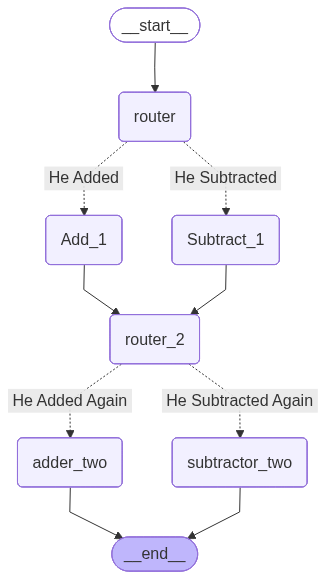

In [7]:
test

In [11]:
ok = test.invoke({"number_1": 5, "operator": "+", "number_2": 3, "number_3": 4})

In [ ]:
ok

{'number_1': 5,
 'number_2': 3,
 'operator': '+',
 'result_1': 8,
 'number_3': 4,
 'result_2': 12}

: 